In [1]:
library(tidyverse)
library(glue)
library(dplyr)

install.packages("showtext")
install.packages("extrafont")
library(extrafont)
font_import()


theme_rangeframe <- function(size = 0.3) {
    theme(
        axis.line = element_line(colour = "black", lineend = "round", size = size),
        axis.ticks = element_line(linewidth = size),
        panel.border = element_blank()
    )
}

scale_axis_rangeframe <- function() {
    guides(x = "axis_truncated", y = "axis_truncated")
}

rotate_x_text <- function(angle=45) {
    theme(
        axis.text.x = element_text(angle = angle, hjust = 1)
    )
}

article_text <- function() {
    theme(
        text = element_text(size = 5, family = "Helvetica"),
        title = element_text(size = 6),
        axis.text.x = element_text(size = 5),
        axis.text.y = element_text(size = 5)
    )
}

no_legend <- function() {
    theme(
        legend.position = "none"
    )
}

no_margin <- function() {
    theme(
        plot.margin = margin(0, 0, 0, 0, unit = "lines")
    )
}

no_label <- function() {
    theme(
        axis.title = element_blank()
    )
}

no_text <- function() {
    theme(
        axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank()
    )
}

no_x_text <- function() {
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )
}

no_y_text <- function() {
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
    )
}


custom_theme <- function(size = 0.3){
    theme_minimal() +
    theme(
        text = element_text(family='Helvetica'),
        axis.line = element_line(colour = "black", lineend = "round", size = size),
        axis.ticks = element_line(linewidth = size),
        panel.border = element_blank()
    )

}
theme_set(custom_theme())

article_text <- function() {
    theme(
        text = element_text(size = 5, family = "Helvetica"),
        title = element_text(size = 6),
        axis.text.x = element_text(size = 5),
        axis.text.y = element_text(size = 5)
    )
}


Warning message:
“package ‘tidyverse’ was built under R version 4.2.3”
Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message:
“package ‘readr’ was built under R version 4.2.3”
Warning message:
“package ‘purrr’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘stringr’ was built under R version 4.2.3”
Warning message:
“package ‘forcats’ was built under R version 4.2.3”
Warning message:
“package ‘lubridate’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package 

Importing fonts may take a few minutes, depending on the number of fonts and the speed of the system.
Continue? [y/n]  y


Scanning ttf files in /usr/share/fonts/ ...

Extracting .afm files from .ttf files...

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-Bold.ttf
 : DejaVuSans-Bold already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-BoldOblique.ttf
 : DejaVuSans-BoldOblique already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-ExtraLight.ttf
 : DejaVuSans-ExtraLight already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans-Oblique.ttf
 : DejaVuSans-Oblique already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSans.ttf
 : DejaVuSans already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSansCondensed-Bold.ttf
 : DejaVuSansCondensed-Bold already registered in fonts database. Skipping.

/usr/share/fonts/dejavu-sans-fonts/DejaVuSansCondensed-BoldOblique.ttf
 : DejaVuSansCondensed-BoldOblique already registered in fonts d

In [3]:
output_dir <- "/lustre/groups/ml01/workspace/ot_perturbation/figures/zebrafish/cell_type_proportion_changes"

In [4]:
data_dir <- "/lustre/groups/ml01/workspace/cell_flow_zebrafish/results/single_condition/cell_type_proportion_downstream"

In [5]:
df <- read_csv(file.path(data_dir, glue("corrs_conditions_all.csv")))

New names:
• `` -> `...1`
Rows: 404 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): cell_type_broad, method, quantile_bin_n_cells, quantile_pert_strength
dbl (5): ...1, pearson, spearman, n_cells_mean, n_cells_var

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
df$method <- factor(df$method, 
                                levels = c("mean", "cl", "cellflow", "single_oligo"),
                                labels = c("mean", "cl", "cellflow", "single_oligo"))  # Correct factorization
color_dict = c(
    "cellflow"="#B12F8C",
    "mean"="#566573",
    "cl"="#E0E0E0",
    "single_oligo"="#BDBDBD")

Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


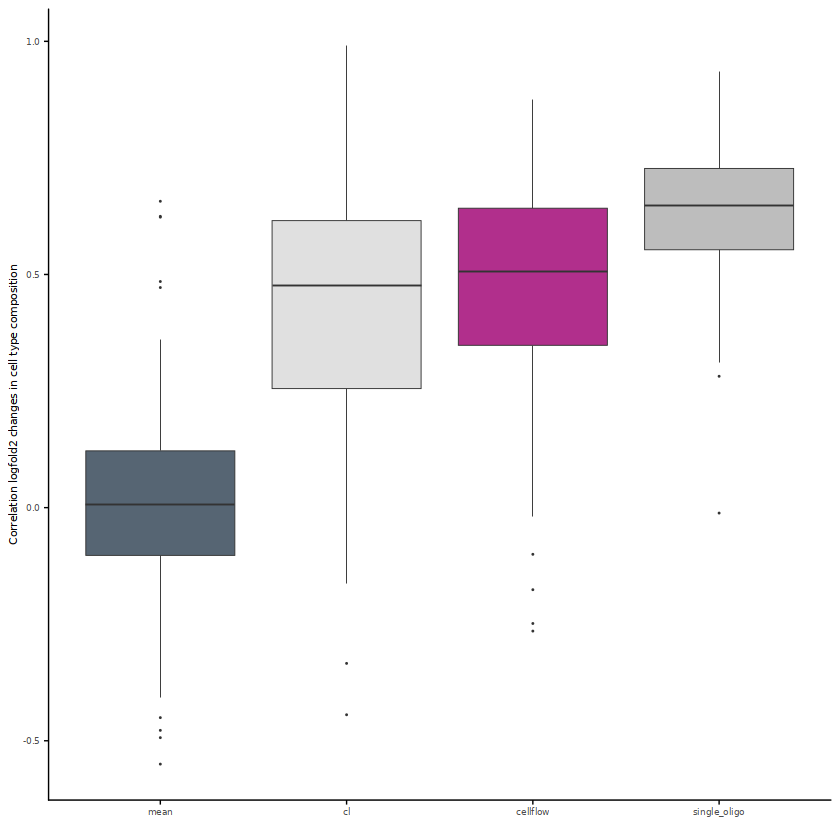

In [9]:
p <- ggplot(df, aes(x=method, y=pearson, fill=method)) +
  geom_boxplot(size=0.2,  width=0.8, outlier.size=0.2, outlier.shape=16) +
  scale_fill_manual(values=color_dict) +  # Removed labels argument
  custom_theme() +
article_text() +
no_legend() +
theme(
    panel.grid.major=element_blank(), 
    panel.grid.minor=element_blank()
)  +
  labs(
    x="",
    y="Correlation logfold2 changes in cell type composition")
   # fill="Timepoint"

p

In [10]:
ggsave(file.path(output_dir, "correlation_logfoldchanges_cell_types_given_condition_all.pdf"), plot = p, device = "pdf",width = 2.5, height = 4.0, unit="cm")

Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


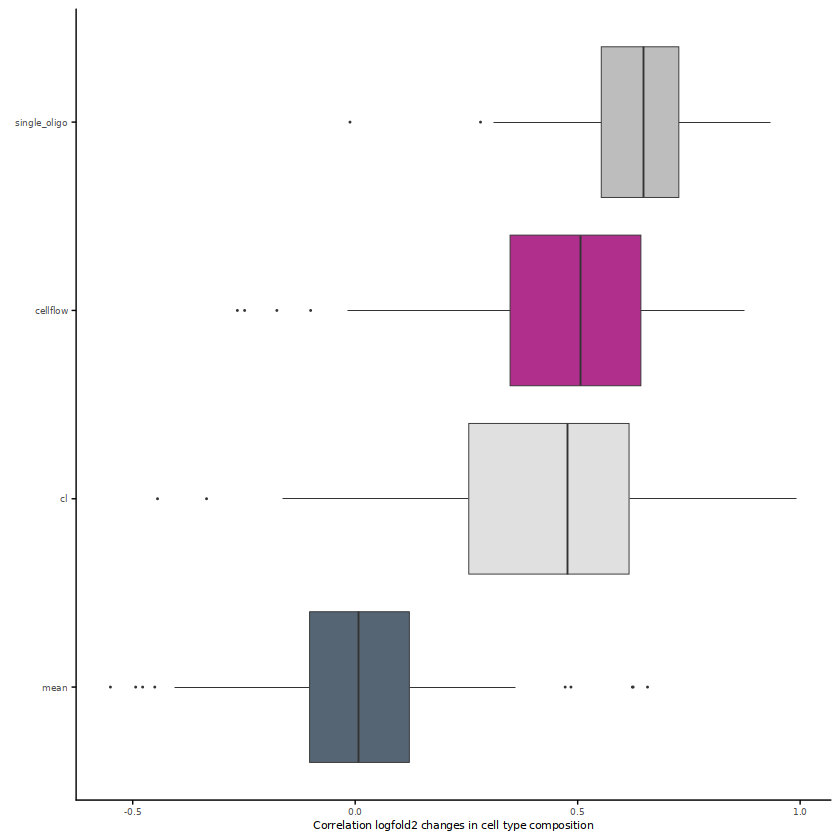

In [11]:
p <- ggplot(df, aes(x=method, y=pearson, fill=method)) +
  geom_boxplot(size=0.2,  width=0.8, outlier.size=0.2, outlier.shape=16) +
  scale_fill_manual(values=color_dict) +  # Removed labels argument
  custom_theme() +
article_text() +
no_legend() +
theme(
    panel.grid.major=element_blank(), 
    panel.grid.minor=element_blank()
)  +
  labs(
    x="",
    y="Correlation logfold2 changes in cell type composition") +
coord_flip()
   # fill="Timepoint"

p

In [12]:
ggsave(file.path(output_dir, "correlation_logfoldchanges_cell_types_given_condition_all.pdf"), plot = p, device = "pdf",width = 4, height = 2.5, unit="cm")


Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


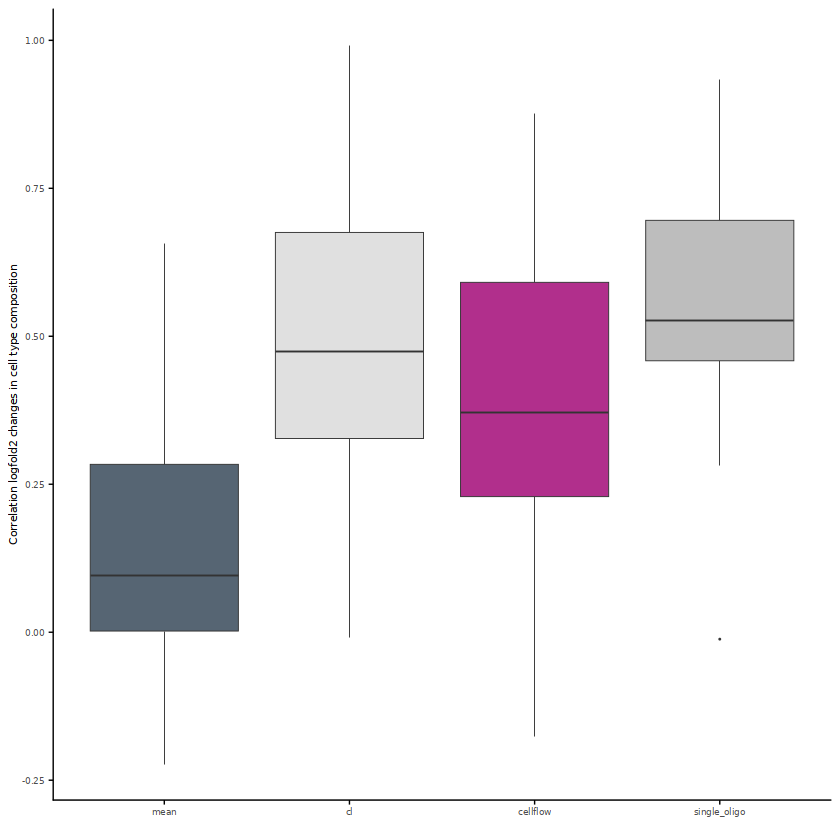

In [19]:
p <- ggplot(df[df$quantile_bin_n_cells=="Q1", ], aes(x=method, y=pearson, fill=method)) +
  geom_boxplot(size=0.2,  width=0.8, outlier.size=0.2, outlier.shape=16) +
  scale_fill_manual(values=color_dict) +  # Removed labels argument
  custom_theme() +
article_text() +
no_legend() +
theme(
    panel.grid.major=element_blank(), 
    panel.grid.minor=element_blank()
)  +
  labs(
    x="",
    y="Correlation logfold2 changes in cell type composition")
   # fill="Timepoint"

p

In [20]:
ggsave(file.path(output_dir, "correlation_logfoldchanges_cell_types_given_condition_q1.pdf"), plot = p, device = "pdf",width = 4, height = 2.5, unit="cm")


Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


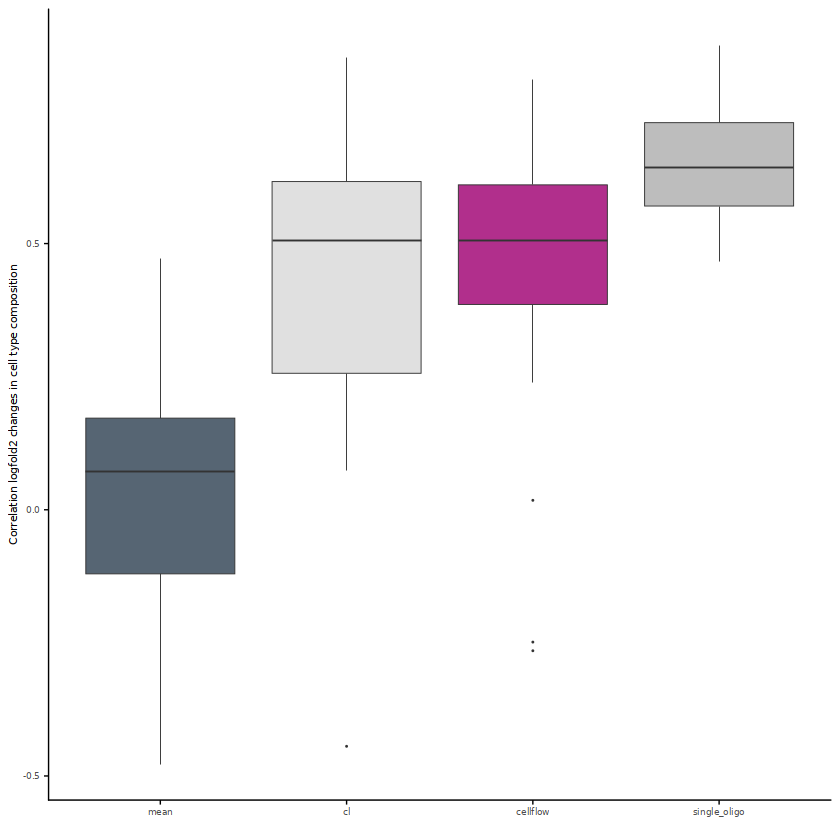

In [21]:
p <- ggplot(df[df$quantile_bin_n_cells=="Q2", ], aes(x=method, y=pearson, fill=method)) +
  geom_boxplot(size=0.2,  width=0.8, outlier.size=0.2, outlier.shape=16) +
  scale_fill_manual(values=color_dict) +  # Removed labels argument
  custom_theme() +
article_text() +
no_legend() +
theme(
    panel.grid.major=element_blank(), 
    panel.grid.minor=element_blank()
)  +
  labs(
    x="",
    y="Correlation logfold2 changes in cell type composition")
   # fill="Timepoint"

p

In [22]:
ggsave(file.path(output_dir, "correlation_logfoldchanges_cell_types_given_condition_q2.pdf"), plot = p, device = "pdf",width = 4, height = 2.5, unit="cm")


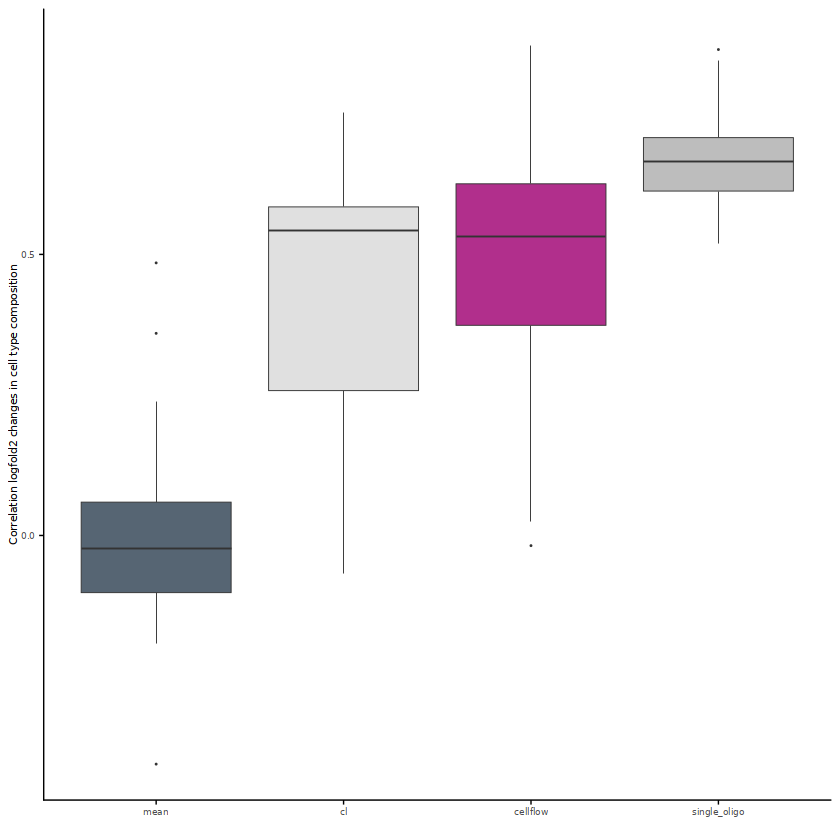

In [23]:
p <- ggplot(df[df$quantile_bin_n_cells=="Q3", ], aes(x=method, y=pearson, fill=method)) +
  geom_boxplot(size=0.2,  width=0.8, outlier.size=0.2, outlier.shape=16) +
  scale_fill_manual(values=color_dict) +  # Removed labels argument
  custom_theme() +
article_text() +
no_legend() +
theme(
    panel.grid.major=element_blank(), 
    panel.grid.minor=element_blank()
)  +
  labs(
    x="",
    y="Correlation logfold2 changes in cell type composition")
   # fill="Timepoint"

p

In [24]:
ggsave(file.path(output_dir, "correlation_logfoldchanges_cell_types_given_condition_q3.pdf"), plot = p, device = "pdf",width = 4, height = 2.5, unit="cm")


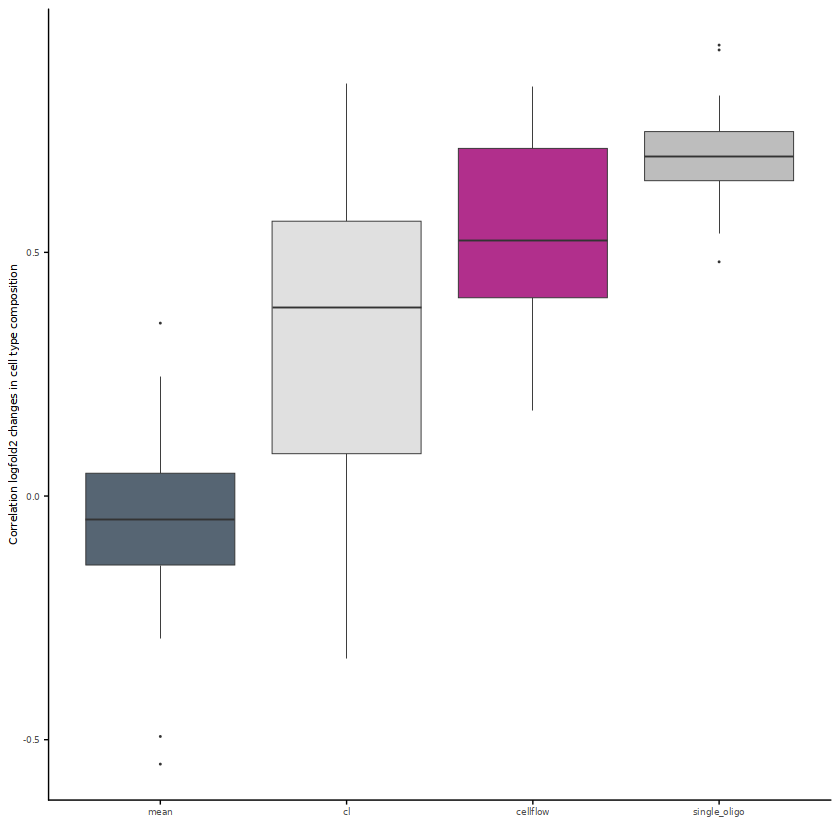

In [25]:
p <- ggplot(df[df$quantile_bin_n_cells=="Q4", ], aes(x=method, y=pearson, fill=method)) +
  geom_boxplot(size=0.2,  width=0.8, outlier.size=0.2, outlier.shape=16) +
  scale_fill_manual(values=color_dict) +  # Removed labels argument
  custom_theme() +
article_text() +
no_legend() +
theme(
    panel.grid.major=element_blank(), 
    panel.grid.minor=element_blank()
)  +
  labs(
    x="",
    y="Correlation logfold2 changes in cell type composition")
   # fill="Timepoint"

p

In [26]:
ggsave(file.path(output_dir, "correlation_logfoldchanges_cell_types_given_condition_q4.pdf"), plot = p, device = "pdf",width = 4, height = 2.5, unit="cm")
